In [40]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from core import *
from utils import *
from lark import Tree, Token
from pm4py import save_vis_petri_net
import random
import pandas as pd
import sys
from sklearn import tree as sktree
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import DBSCAN
#print(f"Versione Python: {sys.version}")

#print(torch.cuda.is_available())
#print(torch.__version__)

# SETTINGS
NARY = 1
PROBABILITIES = 0.2,0.2,0.2,0.4
FILE_PATH_PNG = "petri_net_output.png"
TRACE_ENC_REG = "data/regions_full.csv"
TRACE_ENC_TAS = "data/tasks_full.csv"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
learning_rate = 3e-4

cpu


In [41]:
iterations = 15  # Quante iterazioni diverse (numero regioni prima di minimizzare in teoria)
current_string = SEED_STRING
for _ in range(iterations):
    current_string = replace_random_underscore(current_string, PROBABILITIES)

process = replace_underscores(current_string)
tree = PARSER.parse(process)

# ALBERI GIOCATTOLO

#1 LOOP
'''tree = Tree('xor', [
    Tree('sequential', [
        Tree('loop', [
            Tree('task', [Token('NAME', 'T1')])
        ]),
        Tree('xor', [
            Tree('task', [Token('NAME', 'T2')]),
            Tree('task', [Token('NAME', 'T3')])
        ])
    ]),
    Tree('parallel', [
        Tree('task', [Token('NAME', 'T4')]),
        Tree('task', [Token('NAME', 'T5')])
    ])
])'''

#2 LOOP
tree = Tree('xor', [
    Tree('sequential', [
        Tree('loop', [
            Tree('task', [Token('NAME', 'T1')])
        ]),
        Tree('xor', [
            Tree('task', [Token('NAME', 'T2')]),
            Tree('task', [Token('NAME', 'T3')])
        ])
    ]),
    Tree('parallel', [
        Tree('loop', [   # loop inserito in un ramo del parallel
            Tree('task', [Token('NAME', 'T4')])
        ]),
        Tree('task', [Token('NAME', 'T5')])
    ])
])

#tree = Tree('xor', [Tree('loop', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])])]), Tree('parallel', [Tree('task', [Token('NAME', 'T4')]), Tree('loop', [Tree('task', [Token('NAME', 'T5')])])])])

#tree = Tree('xor', [Tree('task', [Token('NAME', 'T1')]),Tree('sequential', [Tree('parallel', [Tree('xor', [Tree('task', [Token('NAME', 'T2')]),Tree('xor', [Tree('task', [Token('NAME', 'T3')]),Tree('task', [Token('NAME', 'T4')])])]),Tree('parallel', [Tree('task', [Token('NAME', 'T5')]),Tree('task', [Token('NAME', 'T6')])])]),Tree('sequential', [Tree('task', [Token('NAME', 'T7')]),Tree('task', [Token('NAME', 'T8')])])])])

#tree = Tree('xor', [Tree('loop', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])])]), Tree('parallel', [Tree('task', [Token('NAME', 'T4')]), Tree('loop', [Tree('task', [Token('NAME', 'T5')])])])])

if NARY: # Se true allora faccio l'albero ennario (semplifico)
    tree = createNAryTree(tree)

#tree = Tree('loop', [Tree('parallel', [Tree('sequential', [Tree('loop', [Tree('parallel', [Tree('task', [Token('NAME', 'T1')]), Tree('task', [Token('NAME', 'T2')])])]), Tree('loop', [Tree('parallel', [Tree('loop', [Tree('task', [Token('NAME', 'T3')])]), Tree('task', [Token('NAME', 'T4')])])])]), Tree('loop', [Tree('sequential', [Tree('task', [Token('NAME', 'T5')]), Tree('loop', [Tree('task', [Token('NAME', 'T6')])])])])])])

print(tree)

Tree('xor', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])]), Tree('parallel', [Tree('loop', [Tree('task', [Token('NAME', 'T4')])]), Tree('task', [Token('NAME', 'T5')])])])


In [42]:
net = PetriNetP(tree)

save_vis_petri_net(
    net.net,
    net.initial_marking,
    net.final_marking,
    FILE_PATH_PNG,
    format="png"
)

# Oggetto Generator
generator = Generator(5000, net)
generator.generateTrace(False) # with False we don't clean the trace

[['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T2',
  'end_T2',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  'end_T3',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T4',
  'end_T4',
  'end_L5',
  'start_T5',
  'end_T5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T2',
  'end_T2',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T5',
  'start_T4',
  'end_T5',
  'end_T4',
  'end_L5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T4',
  'start_T5',
  'end_T5',
  'end_T4',
  'end_L5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T5',
  

In [43]:
classifier_dict_loop = {}

for loop in net.loop_regions:
    result = create_loop_data(loop, generator.generatedTraces)
    if result is None:
        continue

    x, y, dict_loop_step_encoding, max_len = result

    decisiontree = sktree.DecisionTreeClassifier(max_depth=5, class_weight='balanced') #Se mettiamo class_weight='balanced' è come se avessimo pompato le tracce
    decisiontree = decisiontree.fit(x, y)

    print(loop)
    classifier_dict_loop[loop] = (decisiontree, dict_loop_step_encoding, max_len)

print(classifier_dict_loop)

L2
L5
{'L2': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'end_T1': 0, 'start_L2': 1, 'start_T1': 2, 'back_L2': 3, 'start_X0': 4, 'PAD': 5}, 43), 'L5': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'end_T5': 0, 'PAD': 1, 'end_T4': 2, 'start_L5': 3, 'start_P4': 4, 'back_L5': 5, 'start_T4': 6, 'start_X0': 7, 'start_T5': 8}, 34)}


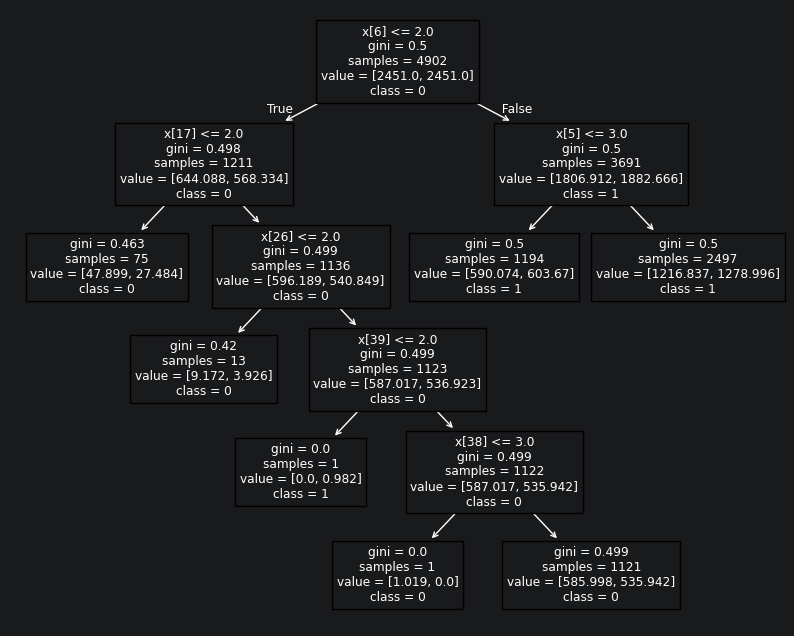

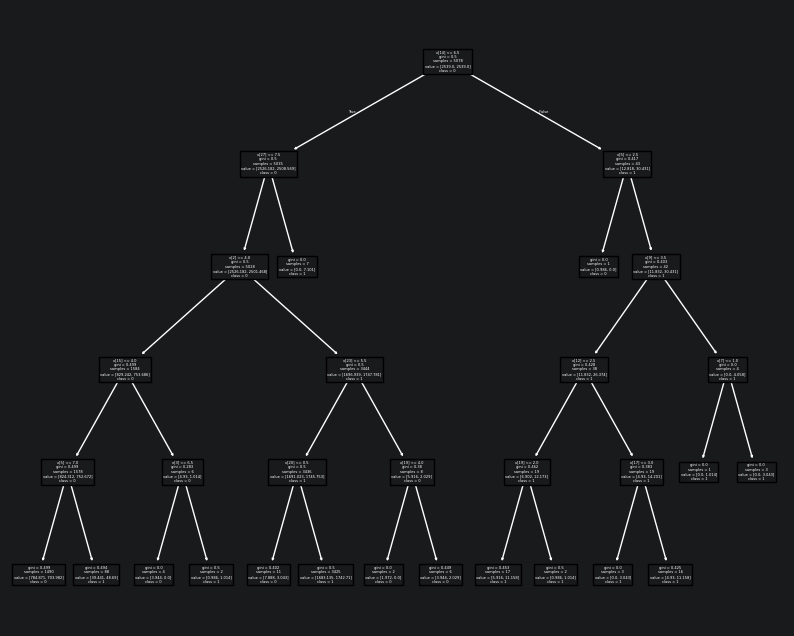

In [44]:
for clf,_,_ in classifier_dict_loop.values():
    plt.figure(figsize=(10, 8))
    sktree.plot_tree(clf,
               class_names=["0", "1"])
    plt.show()

In [45]:
# Rigenero le tracce utilizzando i classificatori
generator.generateTraceCond(classifier_dict_loop)

[['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T4', 'start_T5', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T4', 'end_T4', 'start_T4', 'start_T5', 'end_T5', 'end_T4', 'end_L5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T5', 'start_T4', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T5', 'start_T4', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2'

In [46]:
# Creazione matrice identità delle regioni
df_region_identity = pd.DataFrame.from_dict(net.node_identity, orient='index').sort_index()
df_region_identity.columns = ['X', '+', '->', '<>']
print(df_region_identity)

# Creazione matrice regioni-figli per le regioni
df_region_children = pd.Series(net.node_children).explode()
df_region_children = pd.crosstab(df_region_children.index, df_region_children)
df_region_children = df_region_children.reindex(index=net.regions, columns=net.regions + net.tasks, fill_value=0)
df_region_children = df_region_children.astype(int)
df_region_children.index.name = None
df_region_children.columns.name = None
print(df_region_children)

# Codifica delle tracce generate
traceEncoded_regions, traceEncoded_tasks = get_encoding(generator.generatedTraces, net.regions, net.tasks, net.open_clauses, net.end_clauses)

# Trovo numero regioni e numero task effettivo (torneranno utili in futuro)
num_regions = len([i for i in traceEncoded_regions.index if str(i).startswith('R')])
num_tasks = len([i for i in traceEncoded_tasks.index if str(i).startswith('T')])

# Creo il dataframe unico (regioni + tasks)
df_traces_complete = pd.concat([traceEncoded_regions, traceEncoded_tasks], axis=0)
print(df_traces_complete)

    X  +  ->  <>
R0  1  0   0   0
R1  0  0   1   0
R2  0  0   0   1
R3  1  0   0   0
R4  0  1   0   0
R5  0  0   0   1
    R0  R1  R2  R3  R4  R5  T1  T2  T3  T4  T5
R0   0   1   0   0   1   0   0   0   0   0   0
R1   0   0   1   1   0   0   0   0   0   0   0
R2   0   0   0   0   0   0   1   0   0   0   0
R3   0   0   0   0   0   0   0   1   1   0   0
R4   0   0   0   0   0   1   0   0   0   0   1
R5   0   0   0   0   0   0   0   0   0   1   0
    0      1      2      3      4      5      6      7      8      9      ...  \
R0      1      1      1      0      1      1      1      0      1      1  ...   
R1      1      1      1      0      1      1      1      0      0      0  ...   
R2      1      0      0      0      1      0      0      0      0      0  ...   
R3      0      0      1      0      0      0      1      0      0      0  ...   
R4      0      0      0      0      0      0      0      0      1      1  ...   
R5      0      0      0      0      0      0      0      0      1 

In [47]:
all_traces = getall_traces(num_regions + num_tasks, df_traces_complete)

trace_counts = Counter(all_traces)
traces_encoded = list(trace_counts.keys())
trace_weights = list(trace_counts.values())
n_traces = len(traces_encoded)

distance_matrix = create_distance_matrix(n_traces, traces_encoded, num_regions + num_tasks)


In [48]:
dbscan = DBSCAN(eps=6, min_samples=1, metric="precomputed")
dbscan.fit(distance_matrix, sample_weight=trace_weights)
cluster_labels = dbscan.labels_

df_clusters = pd.DataFrame({
    'Trace_Type': [str(t) for t in traces_encoded],
    'Frequency': trace_weights,
    'N_Cluster': cluster_labels
})
df_clusters = df_clusters.sort_values(by=['N_Cluster', 'Frequency'], ascending=[True, False])

# Visualizzo raggruppando dataframe per Cluster --> SOLO a scopo di visualizzazione
'''
for cluster_id, group in df_clusters.groupby('N_Cluster'):
    num_tracce_cluster = group['Frequency'].sum()
    varianti_per_cluster = len(group)

    print(f"\nCluster {cluster_id}")
    print(f"   ↳ {varianti_per_cluster} varianti uniche -> Rappresentano {num_tracce_cluster} tracce totali")

    varianti = group.head()
    for index, row in varianti.iterrows():
        traccia_str = row['Trace_Type']

        if len(traccia_str) > 80:
            traccia_str = traccia_str[:77] + "..."

        print(f"Freq: {row['Frequency']:<5} | Traccia: {traccia_str}")
'''


'\nfor cluster_id, group in df_clusters.groupby(\'N_Cluster\'):\n    num_tracce_cluster = group[\'Frequency\'].sum()\n    varianti_per_cluster = len(group)\n\n    print(f"\nCluster {cluster_id}")\n    print(f"   ↳ {varianti_per_cluster} varianti uniche -> Rappresentano {num_tracce_cluster} tracce totali")\n\n    varianti = group.head()\n    for index, row in varianti.iterrows():\n        traccia_str = row[\'Trace_Type\']\n\n        if len(traccia_str) > 80:\n            traccia_str = traccia_str[:77] + "..."\n\n        print(f"Freq: {row[\'Frequency\']:<5} | Traccia: {traccia_str}")\n'

In [49]:
num_trace_per_cluster = 1000
balanced_traces, balanced_columns = get_balance_traces_by_cluster(traces_encoded, cluster_labels, num_trace_per_cluster)

df_traces_balanced = pd.DataFrame(balanced_columns).T  # Trasposta
df_traces_balanced.index = df_traces_complete.index
print(df_traces_balanced)

    0      1      2      3      4      5      6      7      8      9      ...  \
R0      1      1      1      0      1      1      1      1      1      0  ...   
R1      1      1      1      0      0      0      0      0      0      0  ...   
R2      1      0      0      0      0      0      0      0      0      0  ...   
R3      0      0      1      0      0      0      0      0      0      0  ...   
R4      0      0      0      0      1      1      1      1      1      0  ...   
R5      0      0      0      0      0      0      1      1      1      0  ...   
T1      1      0      0      0      0      0      0      0      0      0  ...   
T2      0      0      0      0      0      0      0      0      0      0  ...   
T3      0      0      1      0      0      0      0      0      0      0  ...   
T4      0      0      0      0      0      0      1      0      1      0  ...   
T5      0      0      0      0      1      0      0      0      0      0  ...   

    21990  21991  21992  21

In [50]:
# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (per REGIONE + TASK)
df_regions = df_traces_balanced.head(num_regions).copy()
df_tasks = df_traces_balanced.tail(num_tasks).copy()

df_traces_balanced = df_traces_balanced.T
df_traces_balanced = df_traces_balanced.copy()

unique_columns_complete = df_traces_balanced.drop_duplicates()
unique_tuple_complete = [tuple(x) for x in unique_columns_complete.values]

bit_to_id_traces_complete = {v: i for i, v in enumerate(unique_tuple_complete)}
id_to_bit_traces_complete = {i: v for i, v in enumerate(unique_tuple_complete)}

vocab_size_complete = len(unique_columns_complete)

encode_complete = lambda a: [bit_to_id_traces_complete[tuple(x)] for x in a]
decode_complete = lambda b: [id_to_bit_traces_complete[x] for x in b]

# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (solo per REGIONE)
df_regions = df_regions.T

unique_columns_regions = df_regions.drop_duplicates()
unique_tuple_regions = [tuple(x) for x in unique_columns_regions.values]

bit_to_id_traces_regions = {v: i for i, v in enumerate(unique_tuple_regions)}
id_to_bit_traces_regions = {i: v for i, v in enumerate(unique_tuple_regions)}

vocab_size_regions = len(unique_columns_regions)

encode_regions = lambda a: [bit_to_id_traces_regions[tuple(x)] for x in a]
decode_regions = lambda b: [id_to_bit_traces_regions[x] for x in b]

# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (solo per TASK)
df_tasks = df_tasks.T

unique_columns_tasks = df_tasks.drop_duplicates()
unique_tuple_tasks = [tuple(x) for x in unique_columns_tasks.values]

bit_to_id_traces_tasks = {v: i for i, v in enumerate(unique_tuple_tasks)}
id_to_bit_traces_tasks = {i: v for i, v in enumerate(unique_tuple_tasks)}

vocab_size_tasks = len(unique_columns_tasks)

encode_tasks = lambda a: [bit_to_id_traces_tasks[tuple(x)] for x in a]
decode_tasks = lambda b: [id_to_bit_traces_tasks[x] for x in b]

In [51]:
# Decodifico le tracce bilanciate con la funzione getDecoding
traces_balanced_decoded = get_decoding(balanced_traces, net.regions, net.tasks)

possible_tasks = [] # For each task we get start_'task' and end_'task'
for task in net.tasks:
    possible_tasks.append(f"start_{task}")
    possible_tasks.append(f"end_{task}")

k_partition = 3
max_depth = 5

tree_times_task_dict = {}
for task in possible_tasks:
    miner = TracePatternMiner()
    miner.root.name = task # Sovrascrivo il nome della radice (sarà la parte di task che sto usando)

    num_traces_for_task = 0
    for trace in traces_balanced_decoded:
        if task in trace: # Se la task è presente nella traccia
            idx = trace.index(task) # Prendo l'indice della task
            subtrace_task = trace[:idx] # Prendo la traccia fino al punto del task (task escluso)
            reversed_subtrace = list(reversed(subtrace_task)) # Giro la traccia presa

            miner.fit_trace(reversed_subtrace, max_depth) # Vado a contarla nel miner
            num_traces_for_task += 1

    if num_traces_for_task == 0 or len(miner.nodes) == 0:
        tree_times_task_dict[task] = {
            "partitions": {"RESIDUALS": {"numTraces": num_traces_for_task, "nodes": []}},
            "times_map": {"RESIDUALS": 0.0} # Se non ha storia, il tempo normalizzato è sempre il minimo (0.0)
        }
        continue

    partitions = miner.select_patterns(num_traces_for_task, k_partition) # Cerco i pattern
    times_map = miner.create_normalized_time_map(partitions) # Creo il mapping time partitions
    tree_times_task_dict[task] = {
        "partitions" : partitions,
        "times_map" : times_map,
    }

    print(task)
    print(times_map)
    print()

{'RESIDUALS': {'numTraces': 1000, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x1644956a0>]}}
Partizione: -start_T1 | Tracce coperte: 1000
end_T1
{'-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 484, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x164497ce0>, <core.models.PatternTree.NodoPattern object at 0x164495250>]}}
Partizione: -end_T1-start_T1 | Tracce coperte: 484
start_T2
{'-end_T1-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 484, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x161f97e60>, <core.models.PatternTree.NodoPattern object at 0x163175580>, <core.models.PatternTree.NodoPattern object at 0x163174230>]}}
Partizione: -start_T2-end_T1-start_T1 | Tracce coperte: 484
end_T2
{'-start_T2-end_T1-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 516, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x163177fb0>, <core.models.PatternTree.NodoPattern object at 0x163176840>]}}
Partizione: -end_T1-start_T1 | Tracce coperte: 516
start_T3
{'-end_T1

In [52]:
times=[]
trace_times_list=[]
window = 5
for trace in traces_balanced_decoded: # Assegno i tempi alle tracce
    this_trace_times = []

    for i, element in enumerate(trace):
        if i == 0:
            this_trace_times.append(0)
            times.append(0)
            continue

        this_current_trace = trace[:i]
        partitions = tree_times_task_dict[element]["partitions"]
        times_map = tree_times_task_dict[element]["times_map"]

        generated_time = assign_time(this_current_trace, times_map, window)
        this_trace_times.append(generated_time)
        times.append(generated_time)

    print(this_trace_times)
    trace_times_list.append(this_trace_times)

[0, 1.0, 1.0, 1.0]
[0, 0.4286, 1.0, 0.4286, 0.1429, 0.4286]
[0, 0.4286, 0.1429, 0.1429, 0.4286, 0.1429]
[0, 0.1429, 0.4286, 0.1429]
[0, 0.4286, 1.0, 0.4286, 0.1429, 0.4286]
[0, 0.1429, 0.1429, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 0.1429, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.1429, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 1.0, 0.4286, 0.1429, 0.4286]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.4286, 0.1429, 0.1429]
[0, 0.4286, 0.1429, 0.1429, 0.4286, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 1.0, 1.0, 0.4286, 0.1429, 0.4286]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 1.0, 1.0, 0.4286, 0.1429, 0.4286]
[0, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.4286, 1.0, 1.0, 0.4286, 0.1429, 0.4286]
[0, 0.4286, 0.1429, 0.4286, 1.0, 1.0]
[0, 0.4286, 0.4286, 1.0, 1.0, 0.4286, 0.1429, 0.4286]
[0, 0.1429, 0.4286, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.42

In [53]:
#all_unique_steps = set(element for trace in generator.generatedTraces for element in trace)
all_unique_steps = set(element for trace in traces_balanced_decoded for element in trace)
all_unique_steps.add("PAD") # Aggiungiamo il carattere speciale
dict_task_step_encoding = {task: i for i, task in enumerate(all_unique_steps)}

classifier_dict_tasks = {}

for task in possible_tasks:
    result = create_task_data(task, traces_balanced_decoded, trace_times_list, dict_task_step_encoding)

    if result is None:
        continue

    x, y, max_len = result

    regression_tree = sktree.DecisionTreeRegressor(max_depth=5)
    regression_tree = regression_tree.fit(x, y)

    print(f"Task: {task} | Esempio prima riga X: {x[0]} | Numero di righe uniche in X: {len(set(tuple(x) for x in x))}")
    print(f"Task: {task} | Max Len Storica: {max_len} | Score R²: {regression_tree.score(x, y):.4f}")
    classifier_dict_tasks[task] = (regression_tree, max_len)

print(classifier_dict_tasks)

Task: end_T1 | Esempio prima riga X: [9] | Numero di righe uniche in X: 1
Task: end_T1 | Max Len Storica: 1 | Score R²: 1.0000
Task: start_T2 | Esempio prima riga X: [1, 9] | Numero di righe uniche in X: 1
Task: start_T2 | Max Len Storica: 2 | Score R²: 1.0000
Task: end_T2 | Esempio prima riga X: [2, 1, 9] | Numero di righe uniche in X: 1
Task: end_T2 | Max Len Storica: 3 | Score R²: 1.0000
Task: start_T3 | Esempio prima riga X: [1, 9] | Numero di righe uniche in X: 1
Task: start_T3 | Max Len Storica: 2 | Score R²: 1.0000
Task: end_T3 | Esempio prima riga X: [5, 1, 9] | Numero di righe uniche in X: 1
Task: end_T3 | Max Len Storica: 3 | Score R²: 1.0000
Task: start_T4 | Esempio prima riga X: [3, 10, 4, 4, 4, 4] | Numero di righe uniche in X: 8
Task: start_T4 | Max Len Storica: 6 | Score R²: 1.0000
Task: end_T4 | Esempio prima riga X: [8, 3, 10, 4, 4, 4, 4] | Numero di righe uniche in X: 14
Task: end_T4 | Max Len Storica: 7 | Score R²: 1.0000
Task: start_T5 | Esempio prima riga X: [4, 4,

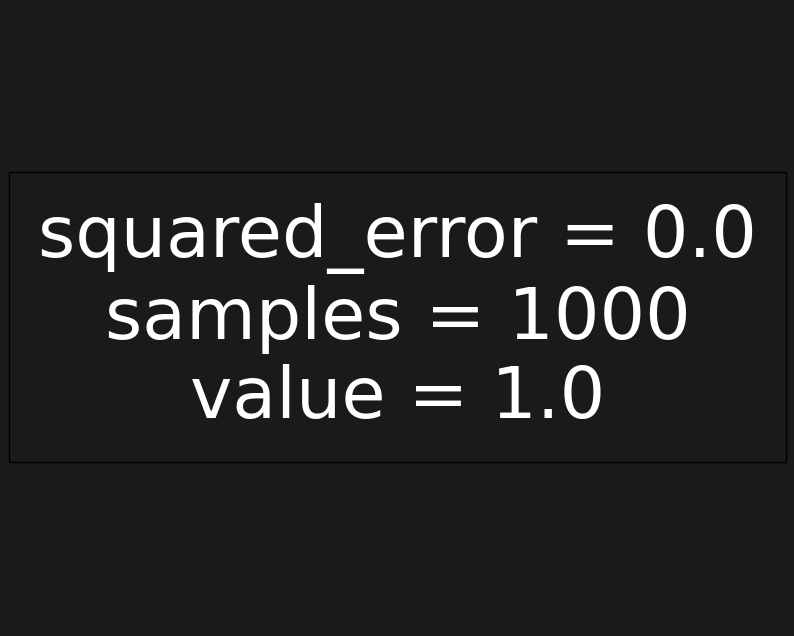

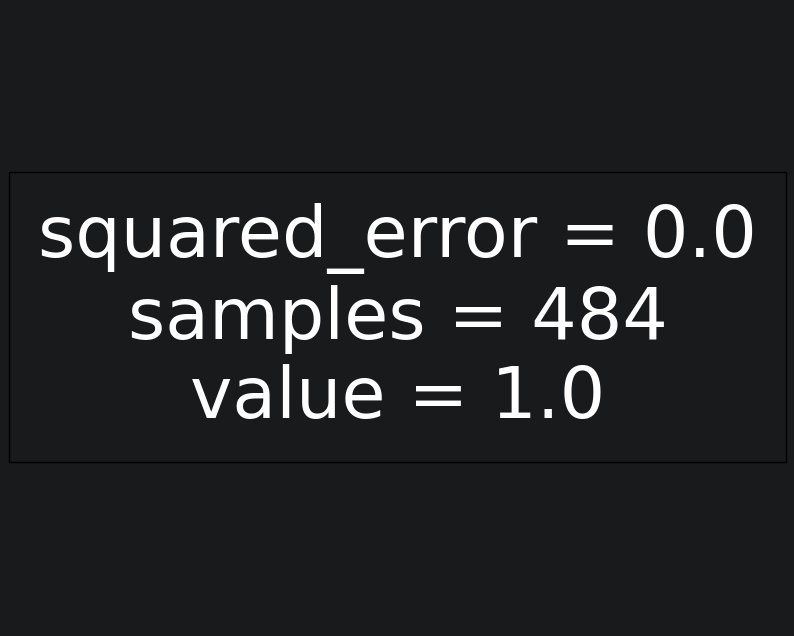

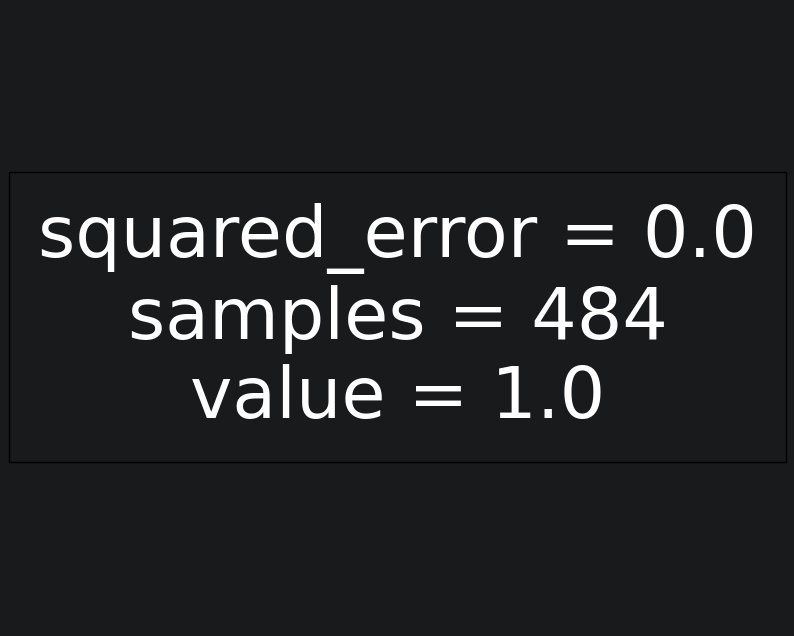

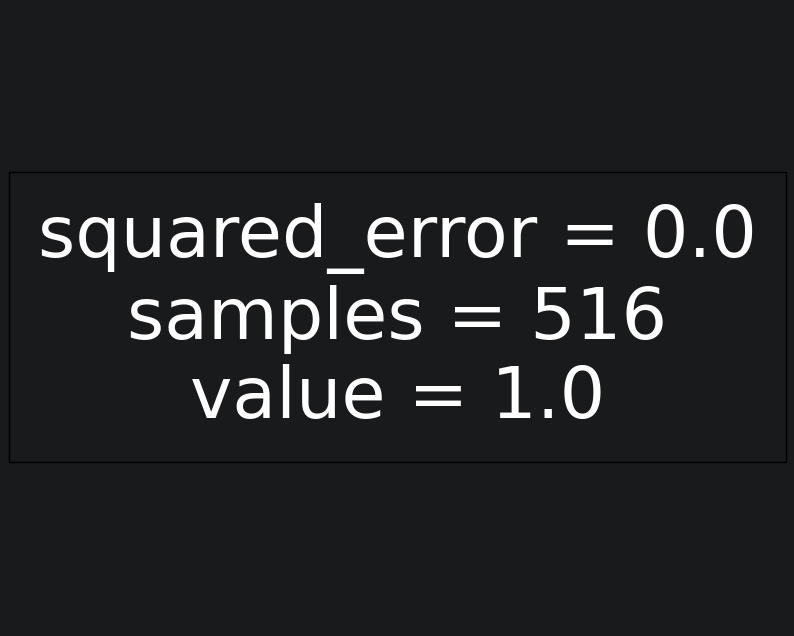

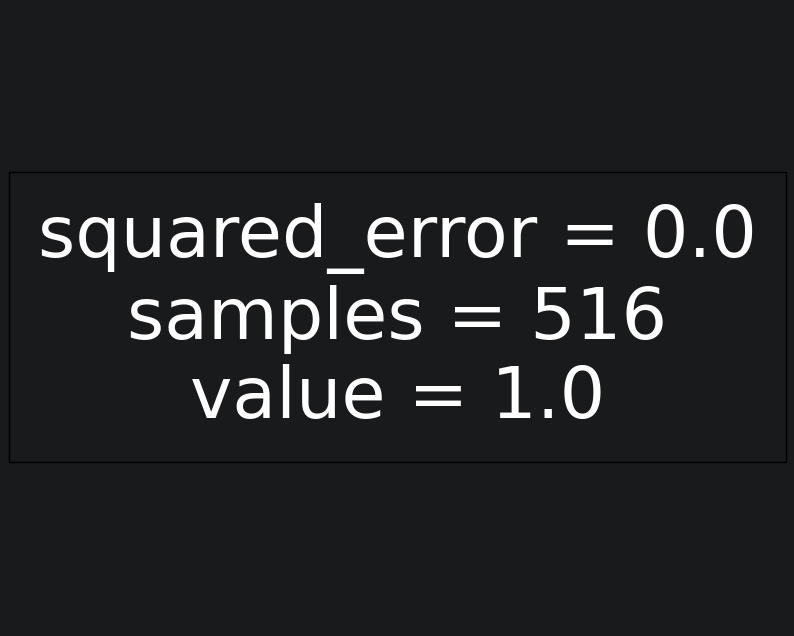

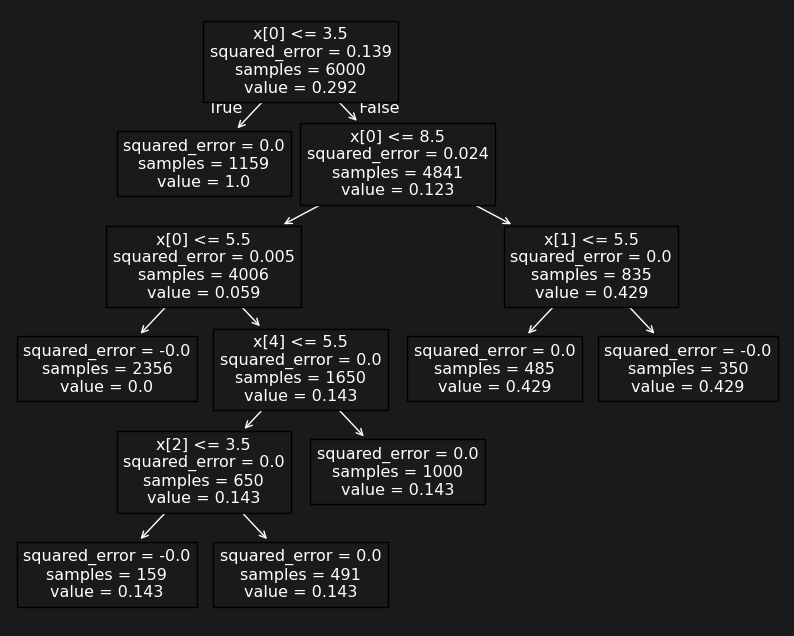

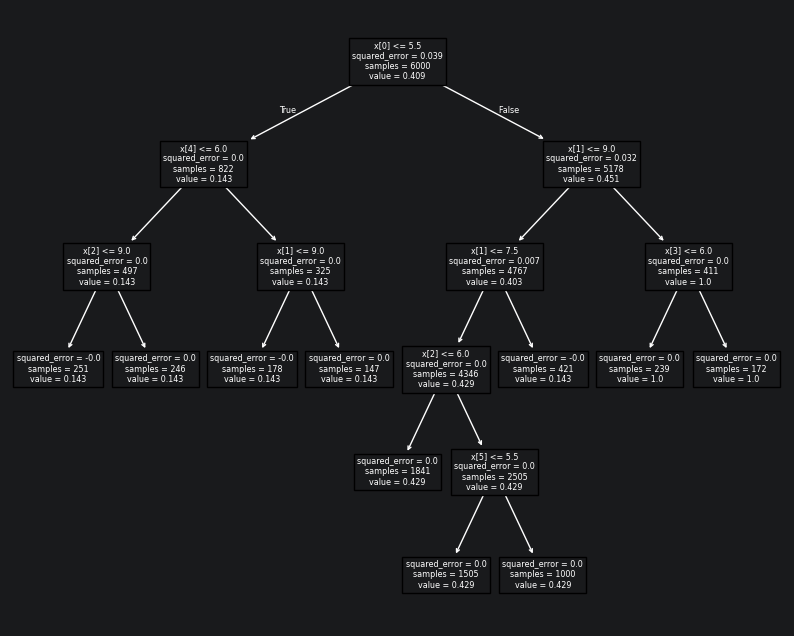

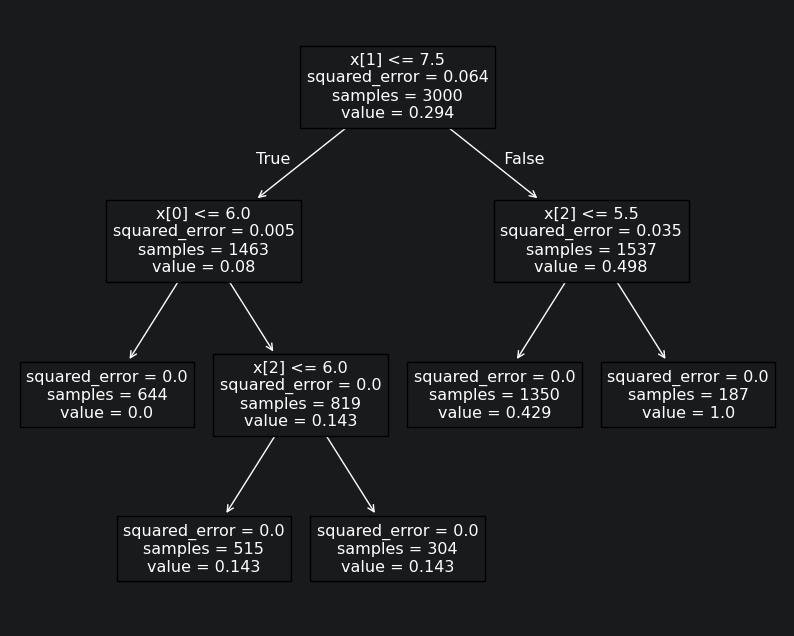

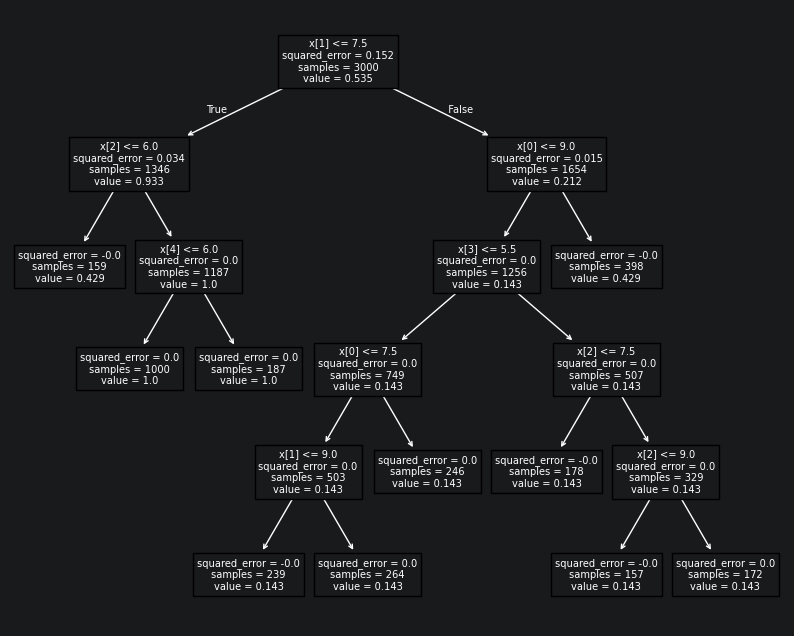

In [54]:
for clf,_ in classifier_dict_tasks.values():
    plt.figure(figsize=(10, 8))
    sktree.plot_tree(clf)
    plt.show()

In [43]:
# Creo il tensor con le colonne codificate in interi
data_complete = torch.tensor(encode_complete(df_traces_balanced.values), dtype=torch.long)
data_regions = torch.tensor(encode_regions(df_regions.values), dtype=torch.long)
data_tasks = torch.tensor(encode_tasks(df_tasks.values), dtype=torch.long)
data_times = torch.tensor(times, dtype=torch.long)

In [44]:
n = int(0.8 * len(df_traces_balanced)) # 80% train, 20% validation

# Valori per il modello completo - REGIONE + TASK
block_size_mc = 256
n_embd_mc = 256
dropout_mc = 0.30
n_head_mc = 8
n_layer_mc = 3
batch_size_mc = 16
eval_iters_mc = 200
eval_interval_mc = 150
max_iters_mc = 500
learning_rate_mc = 3e-4

# Creazione modello BPMNTransformer - Token --> REGIONE + TASK
model_complete = BPMNTransformer(vocab_size_complete, block_size_mc, n_embd_mc, dropout_mc, n_head_mc, n_layer_mc)
m_c = model_complete.to(device)

optimizer_m = torch.optim.AdamW(model_complete.parameters(), lr=learning_rate_mc) # Ottimizzatore pyTorch

train_data = data_complete[:n]
val_data = data_complete[n:]

# print(sum(p.numel() for p in m.parameters()) / 1e6, 'M parameters') # Calcolo parametri modelli

In [45]:
# Funzione presa dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mc):
    if iter % eval_interval_mc == 0 or iter == max_iters_mc - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss(model_complete, eval_iters_mc, train_data, val_data, batch_size_mc, block_size_mc, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_model('train', train_data, val_data, batch_size_mc, block_size_mc, device) # Pesco tracce

    logits, loss = model_complete(xb, yb) # Esegue il forward e predice
    optimizer_m.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_m.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 2.4069, val loss 2.4050
step 150: train loss 0.7753, val loss 0.7651
step 300: train loss 0.7246, val loss 0.7173
step 450: train loss 0.6312, val loss 0.6259
step 499: train loss 0.5688, val loss 0.5621


In [46]:
# Valori per il modello time
block_size_mt = 64
n_embd_mt = 128
dropout_mt = 0.30
n_head_mt = 8
n_layer_mt = 3
batch_size_mt = 16
eval_iters_mt = 200
eval_interval_mt = 150
max_iters_mt = 3000
learning_rate_mt = 3e-4

# Creazione modello TimeTransformer
time_model = TimeTransformer(vocab_size_complete, block_size_mt, n_embd_mt, dropout_mt, n_head_mt, n_layer_mt)
m_t = time_model.to(device)

optimizer_t = torch.optim.AdamW(time_model.parameters(), lr=learning_rate_mt) # Ottimizzatore pyTorch

train_times = data_times[:n]
val_times = data_times[n:]

print(n)
print(len(train_times))
print(len(val_times))

41600
41600
10400


In [47]:
# Funzione presa dal video di karpathy (alleno il modello del Tempo - adattata)
for iter in range(max_iters_mt):
    if iter % eval_interval_mt == 0 or iter == max_iters_mt - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_times(time_model, eval_iters_mt, train_data, train_times, val_data, val_times, batch_size_mt, block_size_mt, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xd, xt, y = get_batch_model_time('train', train_data, train_times, val_data, val_times, batch_size_mt, block_size_mt, device) # Pesco tracce

    logits, loss = time_model(xd, xt, y) # Esegue il forward e predice
    optimizer_t.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_t.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 0.4363, val loss 0.4392
step 150: train loss 0.0872, val loss 0.0850
step 300: train loss 0.0392, val loss 0.0382
step 450: train loss 0.0168, val loss 0.0162
step 600: train loss 0.0116, val loss 0.0117
step 750: train loss 0.0066, val loss 0.0063
step 900: train loss 0.0060, val loss 0.0059
step 1050: train loss 0.0044, val loss 0.0043
step 1200: train loss 0.0035, val loss 0.0035
step 1350: train loss 0.0049, val loss 0.0045
step 1500: train loss 0.0040, val loss 0.0040
step 1650: train loss 0.0045, val loss 0.0039
step 1800: train loss 0.0039, val loss 0.0039
step 1950: train loss 0.0036, val loss 0.0036
step 2100: train loss 0.0031, val loss 0.0032
step 2250: train loss 0.0039, val loss 0.0040
step 2400: train loss 0.0036, val loss 0.0036
step 2550: train loss 0.0041, val loss 0.0040
step 2700: train loss 0.0033, val loss 0.0034
step 2850: train loss 0.0040, val loss 0.0039
step 2999: train loss 0.0039, val loss 0.0038


In [48]:
# Valori per il modello completo - SOLO TASK
block_size_mtask = 256
n_embd_mtask = 256
dropout_mtask = 0.30
n_head_mtask = 8
n_layer_mtask = 3
batch_size_mtask = 16
eval_iters_mtask = 200
eval_interval_mtask = 150
max_iters_mtask = 500
learning_rate_mtask = 3e-4

# Creazione modello BPMNTransformer - Token --> SOLO TASK
model_task = BPMNTransformer(vocab_size_tasks, block_size_mtask, n_embd_mtask, dropout_mtask, n_head_mtask, n_layer_mtask)
m_task = model_task.to(device)

optimizer_mtask = torch.optim.AdamW(model_task.parameters(), lr=learning_rate_mtask) # Ottimizzatore pyTorch

train_data_task = data_tasks[:n]
val_data_task = data_tasks[n:]

In [49]:
print(n)
print(len(train_data_task))
print(len(val_data_task))

# Funzione presa dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mtask):
    if iter % eval_interval_mtask == 0 or iter == max_iters_mtask - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss(model_task, eval_iters_mtask, train_data_task, val_data_task, batch_size_mtask, block_size_mtask, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_model('train', train_data_task, val_data_task, batch_size_mtask, block_size_mtask, device) # Pesco tracce

    logits, loss = model_task(xb, yb) # Esegue il forward e predice
    optimizer_mtask.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_mtask.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

41600
41600
10400
step 0: train loss 2.1108, val loss 2.1160
step 150: train loss 0.6511, val loss 0.6416
step 300: train loss 0.5901, val loss 0.5846
step 450: train loss 0.5755, val loss 0.5694
step 499: train loss 0.5739, val loss 0.5689


In [50]:
# Valori per il modello completo - SOLO TASK
block_size_mregion = 256
n_embd_mregion = 256
dropout_mregion = 0.30
n_head_mregion = 8
n_layer_mregion = 3
batch_size_mregion = 16
eval_iters_mregion = 200
eval_interval_mregion = 150
max_iters_mregion = 500
learning_rate_mregion = 3e-4

# Creazione modello BPMNTransformer - Token --> SOLO TASK
model_region = RegionTransformer(vocab_size_regions, vocab_size_tasks, block_size_mregion, n_embd_mregion, dropout_mregion, n_head_mregion, n_layer_mregion)
m_region = model_region.to(device)

optimizer_mregion = torch.optim.AdamW(model_region.parameters(), lr=learning_rate_mregion) # Ottimizzatore pyTorch

train_data_region = data_regions[:n]
val_data_region = data_regions[n:]

In [51]:
# Funzione presa dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mregion):
    if iter % eval_interval_mregion == 0 or iter == max_iters_mregion - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_region(model_region, eval_iters_mregion, train_data_task, train_data_region, val_data_task, val_data_region, batch_size_mregion, block_size_mregion, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    x_task, x_region, y = get_batch_model_region('train', train_data_task, val_data_task, train_data_region, val_data_region, batch_size_mregion, block_size_mregion, device) # Pesco tracce

    logits, loss = model_region(x_region, x_task, y) # Esegue il forward e predice
    optimizer_mregion.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_mregion.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 2.1239, val loss 2.1303
step 150: train loss 0.2677, val loss 0.2651
step 300: train loss 0.2375, val loss 0.2379
step 450: train loss 0.1662, val loss 0.1673
step 499: train loss 0.1466, val loss 0.1486


In [52]:
# Valori per il modello time v2
block_size_mt_v2 = 64
n_embd_mt_v2 = 128
dropout_mt_v2 = 0.30
n_head_mt_v2 = 8
n_layer_mt_v2 = 3
batch_size_mt_v2 = 16
eval_iters_mt_v2 = 200
eval_interval_mt_v2 = 150
max_iters_mt_v2 = 3000
learning_rate_mt_v2 = 3e-4

# Creazione modello TimeTransformerV2
time_model_v2 = TimeTransformerV2(vocab_size_tasks, vocab_size_regions, block_size_mt_v2, n_embd_mt_v2, dropout_mt_v2, n_head_mt_v2, n_layer_mt_v2)
m_t_v2 = time_model_v2.to(device)

optimizer_t_v2 = torch.optim.AdamW(time_model_v2.parameters(), lr=learning_rate_mt_v2) # Ottimizzatore pyTorch

train_times = data_times[:n]
val_times = data_times[n:]

In [53]:
# Funzione presa dal video di karpathy (alleno il modello del Tempo - adattata per la versione V2 del TimeTransformer (task e regioni separate))
for iter in range(max_iters_mt_v2):
    if iter % eval_interval_mt_v2 == 0 or iter == max_iters_mt_v2 - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_times_v2(time_model_v2, eval_iters_mt_v2, train_data_task, train_data_region, train_times, val_data_task, val_data_region, val_times, batch_size_mt_v2, block_size_mt_v2, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xta, xr, xt, y = get_batch_model_time_v2('train', train_data_task, train_data_region, train_times, val_data_task, val_data_region, val_times, batch_size_mt_v2, block_size_mt_v2, device) # Pesco tracce

    logits, loss = time_model_v2(xta, xr, xt, y) # Esegue il forward e predice
    optimizer_t_v2.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_t_v2.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 0.4056, val loss 0.4065
step 150: train loss 0.0906, val loss 0.0876
step 300: train loss 0.0527, val loss 0.0500
step 450: train loss 0.0193, val loss 0.0179
step 600: train loss 0.0089, val loss 0.0086
step 750: train loss 0.0066, val loss 0.0065
step 900: train loss 0.0047, val loss 0.0045
step 1050: train loss 0.0051, val loss 0.0046
step 1200: train loss 0.0050, val loss 0.0047
step 1350: train loss 0.0040, val loss 0.0037
step 1500: train loss 0.0038, val loss 0.0037
step 1650: train loss 0.0047, val loss 0.0044
step 1800: train loss 0.0043, val loss 0.0042
step 1950: train loss 0.0043, val loss 0.0043
step 2100: train loss 0.0042, val loss 0.0041
step 2250: train loss 0.0044, val loss 0.0043
step 2400: train loss 0.0033, val loss 0.0032
step 2550: train loss 0.0040, val loss 0.0039
step 2700: train loss 0.0044, val loss 0.0043
step 2850: train loss 0.0040, val loss 0.0039
step 2999: train loss 0.0045, val loss 0.0043


In [67]:
# Generazione - REGIONE+TASK --> Time

context = torch.tensor(encode_complete([[0]*(num_regions+num_tasks)]), dtype=torch.long, device=device).unsqueeze(0)
context_time = torch.tensor([0], dtype=torch.float32, device=device).unsqueeze(0) # Lo zero sembra corretto al momento (da verificare, sembrerebbe andare bene anche 1)

# Faccio indovinare il primo time (per (0,0,0,...,0) --> cosi prende meglio il contesto, altrimenti inizia a cannare i primi valori)
first_time_guess = m_t.predict_next_time(idx_tasks=context, idx_times=context_time, block_size=block_size_mt)
#first_time_guess = torch.round(first_time_guess)
context_time = torch.cat((context_time, first_time_guess), dim=1)

max_new_tokens = 30
generated_indices_completegen = []
generated_times_completegen = []
for step in range(max_new_tokens):
    # CON MASCHERA 0 FINALE
    '''next_id = m.predict_next_task(idx=context, block_size=block_size)
    context = torch.cat((context, next_id), dim=1)
    context_time_fake = torch.cat((context_time, fake_time), dim=1)
    next_time = t.predict_next_time(idx_tasks=context, idx_times=context_time_fake, block_size=block_size)
    next_time = torch.round(next_time)
    context_time = torch.cat((context_time, next_time), dim=1)
    generated_indices.append(next_id.item())
    generated_times.append(next_time.item())'''

    # CON SLIDING WINDOW
    next_id = m_c.predict_next_task(idx=context, block_size=block_size_mc)
    context = torch.cat((context, next_id), dim=1)
    next_time = m_t.predict_next_time(idx_tasks=context, idx_times=context_time, block_size=block_size_mt)
    #next_time = torch.round(next_time)
    context_time = torch.cat((context_time, next_time), dim=1)
    generated_indices_completegen.append(next_id.item())
    generated_times_completegen.append(next_time.item())

decoded_output_complete_firstgen = decode_complete(generated_indices_completegen)

for i in range(len(decoded_output_complete_firstgen)):
    step = decoded_output_complete_firstgen[i]
    bit_list = [int(b) for b in step]

    time = generated_times_completegen[i]

    '''if i>0:
        real_time = time_intra_token[tuple(decoded_output_complete_firstgen[i-1]),tuple(decoded_output_complete_firstgen[i])]
    else:
        real_time = time_intra_token[tuple([0]*(num_regions+num_tasks)),tuple(decoded_output_complete_firstgen[i])]
    print(f"{bit_list} - {time} - {real_time}")'''
    print(f"{bit_list} - {round(time,4)}")

[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0] - 0.0085
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.9697
[1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0] - 1.0075
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.9927
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0074
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.0063
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1] - 0.0037
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.0061
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0038
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0046
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0034
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.0046
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1] - 0.0041
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0] - 0.0049
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 1.0157
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.0046
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0064
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.0042
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0045
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.004
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0038
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0057
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0045
[0, 0, 0, 0,

In [68]:
# Funzione per unire Task e Region in un ID compatibile col TimeTransformer --> ADESSO IN TEORIA NON SERVE PIU'
def get_complete_token(task_tensor, region_tensor):
    t_int = task_tensor.item()
    r_int = region_tensor.item()

    t_decoded = decode_tasks([t_int])[0]
    r_decoded = decode_regions([r_int])[0]

    decoding = [int(b) for b in r_decoded] + [int(b) for b in t_decoded]

    try:
        c_encoded = encode_complete([decoding])[0]
        return True, torch.tensor([[c_encoded]], dtype=torch.long, device=device)
    except:
        return False, decoding

In [82]:
# Generazione - TASK --> REGIONE --> Time
context_task = torch.tensor(encode_tasks([[0]*num_tasks]), dtype=torch.long, device=device).unsqueeze(0)
context_region = torch.tensor(encode_regions([[0]*num_regions]), dtype=torch.long, device=device).unsqueeze(0)
context_time = torch.tensor([0], dtype=torch.float32, device=device).unsqueeze(0) # Lo zero sembra corretto al momento (da verificare, sembrerebbe andare bene anche 1)

max_new_tokens = 30
generated_indices_task = []
generated_indices_region = []
generated_times_partgen = []
for step in range(max_new_tokens):
    next_task = m_task.predict_next_task(idx=context_task, block_size=block_size_mtask)
    context_task = torch.cat((context_task, next_task), dim=1)

    context_task_aligned = context_task[:, 1:]

    next_region = m_region.predict_next_region(idx_region=context_region, idx_task=context_task_aligned, block_size=block_size_mregion)
    context_region = torch.cat((context_region, next_region), dim=1)

    context_region_aligned = context_region[:, 1:]

    next_time = m_t_v2.predict_next_time(idx_tasks=context_task_aligned, idx_regions=context_region_aligned, idx_times=context_time, block_size=block_size_mt_v2)
    #next_time = torch.round(next_time)
    context_time = torch.cat((context_time, next_time), dim=1)

    generated_indices_task.append(next_task.item())
    generated_indices_region.append(next_region.item())
    generated_times_partgen.append(next_time.item())

decoded_output_complete_secondgen = []

for i in range(max_new_tokens):
    t_int = generated_indices_task[i]
    r_int = generated_indices_region[i]

    t_bits = [int(b) for b in decode_tasks([t_int])[0]]
    r_bits = [int(b) for b in decode_regions([r_int])[0]]

    bit_list = r_bits + t_bits

    time = generated_times_partgen[i]

    if i > 0:
        past_t_bits = [int(b) for b in decode_tasks([generated_indices_task[i-1]])[0]]
        past_r_bits = [int(b) for b in decode_regions([generated_indices_region[i-1]])[0]]
        past_bit_list = past_r_bits + past_t_bits

        key = (tuple(past_bit_list), tuple(bit_list))
    else:
        key = (tuple([0]*(num_regions+num_tasks)), tuple(bit_list))

    decoded_output_complete_secondgen.append(tuple(bit_list))

    '''if key in time_intra_token:
        real_time = time_intra_token[key]
    else:
        real_time = None

    print(f"{bit_list} - {time} - {real_time}")'''
    print(f"{bit_list} - {round(time,4)}")


[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0634
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0447
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0327
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0872
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1] - 0.0046
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0057
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 1.0141
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0065
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0098
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.9698
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1] - 0.0064
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.0046
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1] - 0.0068
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.0058
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1] - 0.8482
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] - 0.0069
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 0.0096
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.0054
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1] - 0.005
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0] - 0.008
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0] - 1.0098
[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1] - 0.0118
[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1] - 0.0052
[1, 0, 0, 0, 

In [83]:
print("\n--- TRACCE GENERATE ---")

decoded_output = decoded_output_complete_firstgen  #decoded_output_complete_firstgen

traces_generated = []
current_trace_generated = []
for i, step in enumerate(decoded_output):
    bit_list = [int(b) for b in step]
    current_trace_generated.append(bit_list)
    if bit_list == [0]*(num_regions+num_tasks):
        traces_generated.append(current_trace_generated)
        current_trace_generated = []
    #print(f"Step {i:02d}: {bit_list}")

traces_generated.remove(traces_generated[0]) #Rimuovo la prima che è sempre [], generata ed inserita dall'algoritmo sopra
for i,trace in enumerate(traces_generated):
    print(f"{i}: {trace}")



--- TRACCE GENERATE ---
0: [[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
1: [[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
2: [[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
3: [[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


In [84]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.objects.log.obj import Trace, Event, EventLog

# Facciamo il decoding delle tracce generate
#print(traces_generated)
traces_decoded = getDecoding(traces_generated, net.regions, net.tasks)
for i,trace in enumerate(traces_decoded):
    print(f"{i}: {trace}")

# Creiamo il l'EventLog di ogni traccia per poi poterla allineare
eventlog_traces = EventLog()
for trace in traces_decoded:
    t = Trace()
    for activity in trace:
        t.append(Event({'concept:name': activity}))
    eventlog_traces.append(t)


check = ["P", "X", "L"]
start = tuple(["start_" + c for c in check])
end = tuple(["end_" + c for c in check if c!="L"]) # si escludono gli end loop
loop = tuple(["back_L"]) + tuple(["end_L"])

silent_transition_prefixes = start + end + loop

model_cost_function = dict()
sync_cost_function = dict()

# METTIAMO 10000 come di default???
for t in net.net.transitions: # Prendo tutte le transizioni
    if t.label is not None and t.label.startswith(silent_transition_prefixes): # Se è una transizione silente,
        model_cost_function[t] = 0
        sync_cost_function[t] = 10000

    elif t.label is None:
        model_cost_function[t] = 0
        sync_cost_function[t] = 10000

    else: # Se è un task vero e proprio
        model_cost_function[t] = 10000
        sync_cost_function[t] = 0

parameters = {
    alignments.Parameters.PARAM_MODEL_COST_FUNCTION: model_cost_function,
    alignments.Parameters.PARAM_SYNC_COST_FUNCTION: sync_cost_function
}

# Eseguiamo l'allineamento
aligned_traces = alignments.apply(eventlog_traces, net.net, net.initial_marking, net.final_marking, parameters=parameters)
for i,trace in enumerate(aligned_traces):
    print(f"{i}: {trace}")

0: ['start_T4', 'start_T5', 'end_T4', 'start_T4', 'end_T5', 'end_T4', 'start_T4', 'end_T4']
1: ['start_T5', 'end_T5', 'start_T4', 'end_T4']
2: ['start_T4', 'end_T4']
3: ['start_T4', 'end_T4', 'start_T4', 'end_T4', 'start_T4', 'end_T4']


aligning log, completed variants ::   0%|          | 0/4 [00:00<?, ?it/s]

0: {'alignment': [('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_L5'), ('start_T4', 'start_T4'), ('start_T5', 'start_T5'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4', 'start_T4'), ('end_T5', 'end_T5'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'end_L5'), ('>>', 'end_P4'), ('>>', 'end_X0')], 'cost': 0, 'visited_states': 20, 'queued_states': 55, 'traversed_arcs': 55, 'lp_solved': 1, 'fitness': 1.0, 'bwc': 120000}
1: {'alignment': [('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_L5'), ('start_T5', 'start_T5'), ('end_T5', 'end_T5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'end_L5'), ('>>', 'end_P4'), ('>>', 'end_X0')], 'cost': 0, 'visited_states': 12, 'queued_states': 32, 'traversed_arcs': 33, 'lp_solved': 1, 'fitness': 1.0, 'bwc': 80000}
2: {'alignment': [('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_T5'), ('>>', 'end_T5'), ('>>', 'start_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'),

In [85]:
check = ["P", "X", "L"]
start = tuple(["start_" + c for c in check])
end = tuple(["end_" + c for c in check if c!="L"]) # si escludono gli end loop
back_loop = tuple(["back_L"])

# Puliamo l'allineamento e otteniamo la traccia allineata più vicina a quella generata
aligned_traces_cleaned = []
for a_trace in aligned_traces:
    trace_cleaned = []
    trace = a_trace['alignment']

    print(trace)

    for _, net_step in trace: #trans --> trans step , net --> real petri net step
        if net_step != None:
            if not (net_step.startswith(start) or net_step.startswith(end) or net_step.startswith(back_loop)) and not net_step=='>>':
                trace_cleaned.append(net_step)

    aligned_traces_cleaned.append(trace_cleaned)


for i,trace in enumerate(aligned_traces_cleaned):
    print(f"{i}: {trace}")

# Codifichiamo le tracce allineati (per poi poterle confrontare con quelle generate dal transformer)
aligned_traceEncoded_regions, aligned_traceEncoded_tasks = getEncoding(aligned_traces_cleaned, net.regions, net.tasks, net.open_clauses, net.end_clauses)
df_aligned_traces = pd.concat([aligned_traceEncoded_regions, aligned_traceEncoded_tasks], axis=0)
print(df_aligned_traces)


[('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_L5'), ('start_T4', 'start_T4'), ('start_T5', 'start_T5'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4', 'start_T4'), ('end_T5', 'end_T5'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'end_L5'), ('>>', 'end_P4'), ('>>', 'end_X0')]
[('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_L5'), ('start_T5', 'start_T5'), ('end_T5', 'end_T5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'end_L5'), ('>>', 'end_P4'), ('>>', 'end_X0')]
[('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_T5'), ('>>', 'end_T5'), ('>>', 'start_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'end_L5'), ('>>', 'end_P4'), ('>>', 'end_X0')]
[('>>', 'start_X0'), ('>>', 'start_P4'), ('>>', 'start_T5'), ('>>', 'end_T5'), ('>>', 'start_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4', 'start_T4'), ('end_T4', 'end_T4'), ('>>', 'back_L5'), ('start_T4

In [86]:
# Creo una lista delle tracce codificate (ogni traccia è una lista dove ogni elemento è una colonna del df, ossia uno step) --> più facili da confrontare quando calcoliamo la distanza
aligned_traces_encoded = []
aligned_trace_encoded = []
for element in df_aligned_traces.T.values:
    element = element.tolist()
    aligned_trace_encoded.append(element)
    if element == [0] * (num_regions+num_tasks):
        aligned_traces_encoded.append(aligned_trace_encoded)
        aligned_trace_encoded = []

# Andiamo a calcolare il costo con la edit distance (weighted_levenshtein)
for i in range(len(aligned_traces_encoded)):
    generated_t = traces_generated[i]
    aligned_t = aligned_traces_encoded[i]

    gen_tuples = [tuple(step) for step in generated_t]
    aligned_tuples = [tuple(step) for step in aligned_t]

    total_possible_column = set(gen_tuples + aligned_tuples) # Prendo tutte le possibili colonne per andare a creare il dizionario delle sostituzioni

    # Se volessi dizionario delle distanze bisognerebbe usare questo pezzo di codice (adesso usiamo distanza di hamming di base nel codice)
    '''cost_sub = {}
    for e1 in total_possible_column:
        for e2 in total_possible_column:
            if e1 != e2:
                counter = 0
                for i in range(len(e1)):
                    if e1[i] != e2[i]:
                        counter+=1
                cost_sub[(e1,e2)] = counter'''

    cost = edit_distance_weighted_levenshtein(generated_t, aligned_t, num_regions+num_tasks, num_regions+num_tasks, hamming_distance) # Utilizziamo la distanza di hamming al momento
    print(cost)

#costo = edit_distance_weighted_levenshtein(traccia_ai, traccia_pulita, cost_ins, cost_del, cost_sub)
#print(f"Costo di correzione totale: {costo}")

1.0
0.0
22.0
22.0
